Connected to .venv (3.12.0) (Python 3.12.0)

 # Fase 2 — Modelagem Supervisionada
 **TechChallenger3 — Previsão de Atrasos de Voos (EUA)**

 Base: 5.714.008 voos completados | Target: IS_DELAYED (17,91% positivos)
 Sem data leakage — apenas features disponíveis antes do embarque

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    mean_squared_error, mean_absolute_error, r2_score,
)
from xgboost import XGBClassifier, XGBRegressor

_ROOT  = Path(__file__).resolve().parent.parent
DADOS  = _ROOT / "dados"
FIGS   = _ROOT / "outputs" / "figures"
MODELS = _ROOT / "outputs" / "models"
FIGS.mkdir(parents=True, exist_ok=True)
MODELS.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 5)})
sns.set_theme(style="whitegrid", palette="muted")

print("Bibliotecas carregadas.")

Bibliotecas carregadas.


 ---
 ## Seção 1 — Carregamento e Preparação Base

In [ ]:
dtype_flights = {
    "YEAR": "int16", "MONTH": "int8", "DAY": "int8", "DAY_OF_WEEK": "int8",
    "AIRLINE": "category", "FLIGHT_NUMBER": "int16",
    "TAIL_NUMBER": "category", "ORIGIN_AIRPORT": "category",
    "DESTINATION_AIRPORT": "category", "SCHEDULED_DEPARTURE": "int32",
    "DEPARTURE_TIME": "float32", "DEPARTURE_DELAY": "float32",
    "TAXI_OUT": "float32", "WHEELS_OFF": "float32", "SCHEDULED_TIME": "float32",
    "ELAPSED_TIME": "float32", "AIR_TIME": "float32", "DISTANCE": "float32",
    "WHEELS_ON": "float32", "TAXI_IN": "float32", "SCHEDULED_ARRIVAL": "int32",
    "ARRIVAL_TIME": "float32", "ARRIVAL_DELAY": "float32",
    "DIVERTED": "int8", "CANCELLED": "int8", "CANCELLATION_REASON": "category",
    "AIR_SYSTEM_DELAY": "float32", "SECURITY_DELAY": "float32",
    "AIRLINE_DELAY": "float32", "LATE_AIRCRAFT_DELAY": "float32",
    "WEATHER_DELAY": "float32",
}

flights = pd.read_csv(DADOS / "flights.csv", dtype=dtype_flights, low_memory=False)

# Remover cancelados e desviados (igual à EDA)
df = flights[(flights["CANCELLED"] == 0) & (flights["DIVERTED"] == 0)].copy()
df = df.dropna(subset=["ARRIVAL_DELAY", "DEPARTURE_DELAY"])

print(f"Voos completados para modelagem: {len(df):,}")

Voos completados para modelagem: 5,714,008


 ---
 ## Seção 2 — Feature Engineering
 Apenas features disponíveis **antes** do embarque (sem leakage)

In [ ]:
# --- Targets ---
df["IS_DELAYED"] = (df["ARRIVAL_DELAY"] > 15).astype("int8")
print(f"Taxa de atraso (IS_DELAYED=1): {df['IS_DELAYED'].mean()*100:.2f}%")

# --- Features temporais ---
df["DEPARTURE_HOUR"]   = (df["SCHEDULED_DEPARTURE"] // 100).astype("int16")
df["DEPARTURE_PERIOD"] = pd.cut(
    df["DEPARTURE_HOUR"],
    bins=[-1, 5, 11, 17, 23],
    labels=["Madrugada", "Manha", "Tarde", "Noite"],
)
df["SEASON"] = df["MONTH"].map({
    12: "Inverno", 1: "Inverno",  2: "Inverno",
    3:  "Primavera", 4: "Primavera", 5: "Primavera",
    6:  "Verao",    7: "Verao",    8: "Verao",
    9:  "Outono",  10: "Outono",  11: "Outono",
})
df["IS_WEEKEND"] = (df["DAY_OF_WEEK"] >= 6).astype("int8")

# --- Features de rota/distância ---
df["ROUTE"] = df["ORIGIN_AIRPORT"].astype(str) + "_" + df["DESTINATION_AIRPORT"].astype(str)
df["DISTANCE_BUCKET"] = pd.cut(
    df["DISTANCE"],
    bins=[0, 500, 1500, 10_000],
    labels=["Curto", "Medio", "Longo"],
)

print("Features criadas:")
print(f"  DEPARTURE_HOUR range: {df['DEPARTURE_HOUR'].min()}–{df['DEPARTURE_HOUR'].max()}")
print(f"  SEASON values: {df['SEASON'].unique().tolist()}")
print(f"  DISTANCE_BUCKET: {df['DISTANCE_BUCKET'].value_counts().to_dict()}")

Taxa de atraso (IS_DELAYED=1): 17.91%
Features criadas:
  DEPARTURE_HOUR range: 0–23
  SEASON values: ['Inverno', 'Primavera', 'Verao', 'Outono']
  DISTANCE_BUCKET: {'Medio': 2849594, 'Curto': 2087046, 'Longo': 777368}


 ---
 ## Seção 3 — Pré-processamento e Split

In [ ]:
# Colunas com leakage — EXCLUIR
LEAKAGE_COLS = [
    "DEPARTURE_DELAY", "DEPARTURE_TIME", "TAXI_OUT", "TAXI_IN",
    "ELAPSED_TIME", "AIR_TIME", "WHEELS_OFF", "WHEELS_ON",
    "AIR_SYSTEM_DELAY", "SECURITY_DELAY", "AIRLINE_DELAY",
    "LATE_AIRCRAFT_DELAY", "WEATHER_DELAY", "ARRIVAL_TIME",
    "ARRIVAL_DELAY", "IS_DELAYED",
]

# Features numéricas diretas
NUM_COLS = ["MONTH", "DAY_OF_WEEK", "DEPARTURE_HOUR", "IS_WEEKEND",
            "DISTANCE", "SCHEDULED_TIME", "SCHEDULED_DEPARTURE"]

# Features categóricas
CAT_LOW  = ["AIRLINE"]                             # 14 únicos → One-Hot
CAT_HIGH = ["ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "ROUTE"]  # alta cardinalidade → Target Enc.
CAT_ORD  = ["DEPARTURE_PERIOD", "SEASON", "DISTANCE_BUCKET"]   # Ordinal → Label Enc.

In [ ]:
# Split estratificado antes de qualquer encoding (previne leakage do target encoding)
y_clf = df["IS_DELAYED"].values
y_reg = df["ARRIVAL_DELAY"].clip(-60, 360).values  # clip outliers extremos para regressão

df_train, df_test, y_train_clf, y_test_clf, y_train_reg, y_test_reg = train_test_split(
    df, y_clf, y_reg,
    test_size=0.20, random_state=42, stratify=y_clf,
)

print(f"Treino : {len(df_train):,} ({y_train_clf.mean()*100:.2f}% atrasados)")
print(f"Teste  : {len(df_test):,}  ({y_test_clf.mean()*100:.2f}% atrasados)")

Treino : 4,571,206 (17.91% atrasados)
Teste  : 1,142,802  (17.91% atrasados)


In [ ]:
# --- One-Hot Encoding: AIRLINE (14 únicos) ---
airline_dummies_train = pd.get_dummies(df_train["AIRLINE"].astype(str), prefix="AL", drop_first=True)
airline_dummies_test  = pd.get_dummies(df_test["AIRLINE"].astype(str),  prefix="AL", drop_first=True)
airline_dummies_test  = airline_dummies_test.reindex(columns=airline_dummies_train.columns, fill_value=0)

# --- Target Encoding: ORIGIN, DESTINATION, ROUTE (fit apenas no treino) ---
def target_encode(train_series, test_series, target, smoothing=10):
    global_mean = target.mean()
    stats = pd.DataFrame({"cat": train_series.astype(str), "y": target})
    agg   = stats.groupby("cat")["y"].agg(["mean", "count"])
    smooth = (agg["count"] * agg["mean"] + smoothing * global_mean) / (agg["count"] + smoothing)
    enc_train = train_series.astype(str).map(smooth).fillna(global_mean).values
    enc_test  = test_series.astype(str).map(smooth).fillna(global_mean).values
    return enc_train, enc_test

orig_tr, orig_te   = target_encode(df_train["ORIGIN_AIRPORT"],      df_test["ORIGIN_AIRPORT"],      y_train_clf)
dest_tr, dest_te   = target_encode(df_train["DESTINATION_AIRPORT"], df_test["DESTINATION_AIRPORT"], y_train_clf)
route_tr, route_te = target_encode(df_train["ROUTE"],               df_test["ROUTE"],               y_train_clf)

# --- Ordinal Encoding: DEPARTURE_PERIOD, SEASON, DISTANCE_BUCKET ---
period_map = {"Madrugada": 0, "Manha": 1, "Tarde": 2, "Noite": 3}
season_map = {"Primavera": 0, "Verao": 1, "Outono": 2, "Inverno": 3}
bucket_map = {"Curto": 0, "Medio": 1, "Longo": 2}

def ord_enc(series, mapping):
    return series.astype(str).map(mapping).fillna(0).values

In [ ]:
# Montar matrizes finais X_train, X_test
def build_X(df_part, a_dum, orig_enc, dest_enc, route_enc):
    base = df_part[NUM_COLS].values.astype("float32")
    period = ord_enc(df_part["DEPARTURE_PERIOD"], period_map).reshape(-1, 1)
    season = ord_enc(df_part["SEASON"],           season_map).reshape(-1, 1)
    bucket = ord_enc(df_part["DISTANCE_BUCKET"],  bucket_map).reshape(-1, 1)
    return np.hstack([
        base,
        a_dum.values,
        orig_enc.reshape(-1, 1),
        dest_enc.reshape(-1, 1),
        route_enc.reshape(-1, 1),
        period, season, bucket,
    ])

X_train = build_X(df_train, airline_dummies_train, orig_tr, dest_tr, route_tr)
X_test  = build_X(df_test,  airline_dummies_test,  orig_te, dest_te, route_te)

feature_names = (
    NUM_COLS
    + list(airline_dummies_train.columns)
    + ["ORIGIN_ENC", "DESTINATION_ENC", "ROUTE_ENC",
       "DEPARTURE_PERIOD_ORD", "SEASON_ORD", "DISTANCE_BUCKET_ORD"]
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test  shape: {X_test.shape}")
print(f"Features totais: {len(feature_names)}")

X_train shape: (4571206, 26)
X_test  shape: (1142802, 26)
Features totais: 26


In [ ]:
# Scaling (apenas para Logistic Regression)
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

 ---
 ## Seção 4 — Classificação: IS_DELAYED

In [ ]:
# Desbalanceamento: 17.91% positivos → scale_pos_weight XGBoost
SPW = (1 - 0.1791) / 0.1791  # ≈ 4.58
print(f"scale_pos_weight XGBoost: {SPW:.2f}")

scale_pos_weight XGBoost: 4.58


 ### 4.1 — Logistic Regression (baseline)

In [ ]:
print("Treinando Logistic Regression...")
lr = LogisticRegression(class_weight="balanced", max_iter=500, C=1.0, random_state=42, n_jobs=-1)
lr.fit(X_train_s, y_train_clf)

lr_pred  = lr.predict(X_test_s)
lr_proba = lr.predict_proba(X_test_s)[:, 1]

print(classification_report(y_test_clf, lr_pred, target_names=["Pontual", "Atrasado"]))
print(f"ROC-AUC: {roc_auc_score(y_test_clf, lr_proba):.4f}")

Treinando Logistic Regression...
              precision    recall  f1-score   support

     Pontual       0.88      0.60      0.72    938102
    Atrasado       0.25      0.61      0.36    204700

    accuracy                           0.61   1142802
   macro avg       0.56      0.61      0.54   1142802
weighted avg       0.77      0.61      0.65   1142802

ROC-AUC: 0.6467


 ### 4.2 — Random Forest

In [ ]:
print("Treinando Random Forest... (pode levar alguns minutos)")
rf = RandomForestClassifier(
    n_estimators=200, max_depth=15, class_weight="balanced",
    random_state=42, n_jobs=-1, min_samples_leaf=50,
)
rf.fit(X_train, y_train_clf)

rf_pred  = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test_clf, rf_pred, target_names=["Pontual", "Atrasado"]))
print(f"ROC-AUC: {roc_auc_score(y_test_clf, rf_proba):.4f}")

Treinando Random Forest... (pode levar alguns minutos)
              precision    recall  f1-score   support

     Pontual       0.89      0.62      0.73    938102
    Atrasado       0.27      0.65      0.38    204700

    accuracy                           0.62   1142802
   macro avg       0.58      0.63      0.56   1142802
weighted avg       0.78      0.62      0.67   1142802

ROC-AUC: 0.6852


 ### 4.3 — XGBoost

In [ ]:
print("Treinando XGBoost...")

# Split de validação interno para early stopping
X_tr_xgb, X_val_xgb, y_tr_xgb, y_val_xgb = train_test_split(
    X_train, y_train_clf, test_size=0.10, random_state=42, stratify=y_train_clf
)

xgb = XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    scale_pos_weight=SPW, random_state=42,
    eval_metric="auc", early_stopping_rounds=20,
    subsample=0.8, colsample_bytree=0.8,
    tree_method="hist", device="cpu",
    verbosity=0,
)
xgb.fit(X_tr_xgb, y_tr_xgb, eval_set=[(X_val_xgb, y_val_xgb)], verbose=False)

xgb_pred  = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test_clf, xgb_pred, target_names=["Pontual", "Atrasado"]))
print(f"ROC-AUC: {roc_auc_score(y_test_clf, xgb_proba):.4f}")
print(f"Melhor iteração: {xgb.best_iteration}")

Treinando XGBoost...
              precision    recall  f1-score   support

     Pontual       0.89      0.62      0.73    938102
    Atrasado       0.27      0.66      0.39    204700

    accuracy                           0.63   1142802
   macro avg       0.58      0.64      0.56   1142802
weighted avg       0.78      0.63      0.67   1142802

ROC-AUC: 0.6897
Melhor iteração: 499


 ### 4.4 — Tabela Comparativa de Métricas (Classificação)

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

results_clf = []
for name, pred, proba in [
    ("Logistic Regression", lr_pred,  lr_proba),
    ("Random Forest",       rf_pred,  rf_proba),
    ("XGBoost",             xgb_pred, xgb_proba),
]:
    results_clf.append({
        "Modelo":    name,
        "Accuracy":  accuracy_score(y_test_clf, pred),
        "Precision": precision_score(y_test_clf, pred),
        "Recall":    recall_score(y_test_clf, pred),
        "F1":        f1_score(y_test_clf, pred),
        "ROC-AUC":   roc_auc_score(y_test_clf, proba),
        "Avg-Precision": average_precision_score(y_test_clf, proba),
    })

df_results_clf = pd.DataFrame(results_clf).set_index("Modelo").round(4)
print("\n=== Tabela Comparativa — Classificação ===")
print(df_results_clf.to_string())

df_results_clf.to_csv(_ROOT / "outputs" / "model_comparison_clf.csv")
print("\nSalvo: outputs/model_comparison_clf.csv")


=== Tabela Comparativa — Classificação ===
                     Accuracy  Precision  Recall      F1  ROC-AUC  Avg-Precision
Modelo                                                                          
Logistic Regression    0.6058     0.2523  0.6114  0.3572   0.6467         0.2688
Random Forest          0.6221     0.2704  0.6532  0.3824   0.6852         0.3213
XGBoost                0.6254     0.2731  0.6566  0.3857   0.6897         0.3275

Salvo: outputs/model_comparison_clf.csv


 ### 4.5 — Plots: Confusion Matrix, ROC Curve, Precision-Recall

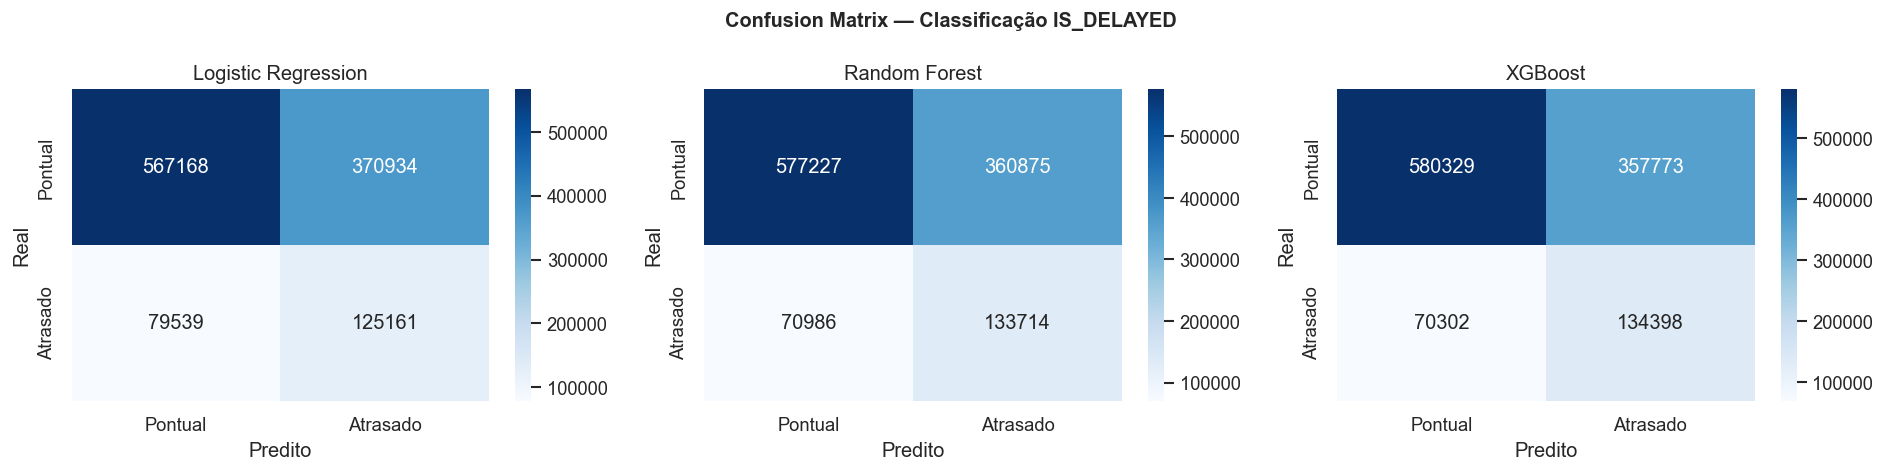

In [ ]:
# Confusion Matrix — os 3 modelos
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, pred) in zip(axes, [
    ("Logistic Regression", lr_pred),
    ("Random Forest",       rf_pred),
    ("XGBoost",             xgb_pred),
]):
    cm = confusion_matrix(y_test_clf, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pontual", "Atrasado"],
                yticklabels=["Pontual", "Atrasado"])
    ax.set_title(name)
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")
plt.suptitle("Confusion Matrix — Classificação IS_DELAYED", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGS / "train_01_confusion_matrix.png")
plt.show()

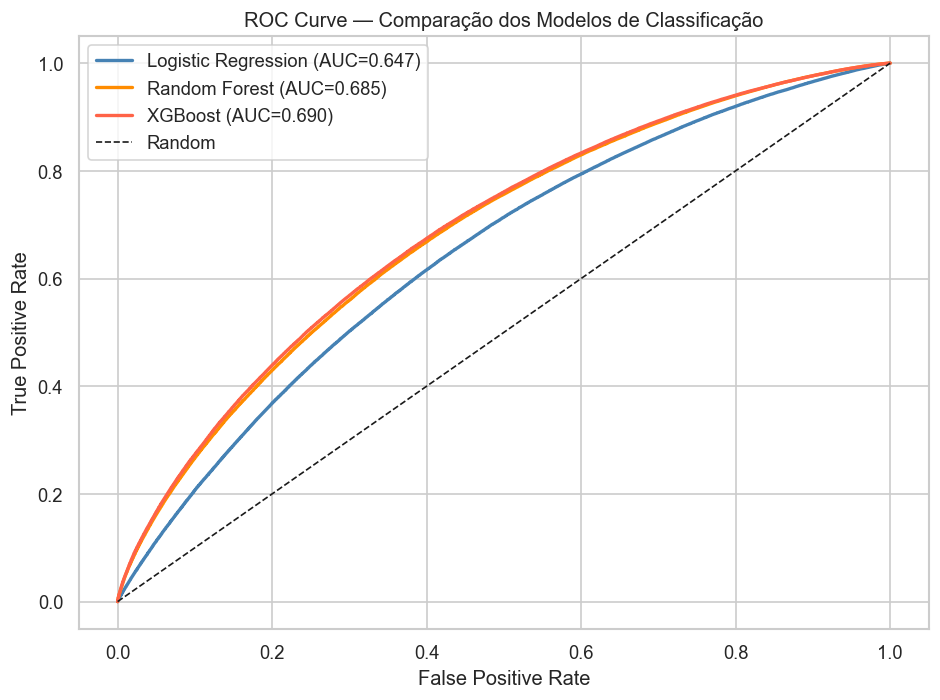

In [ ]:
# ROC Curve — os 3 modelos sobrepostos
fig, ax = plt.subplots(figsize=(8, 6))
for name, proba, color in [
    ("Logistic Regression", lr_proba,  "steelblue"),
    ("Random Forest",       rf_proba,  "darkorange"),
    ("XGBoost",             xgb_proba, "tomato"),
]:
    fpr, tpr, _ = roc_curve(y_test_clf, proba)
    auc = roc_auc_score(y_test_clf, proba)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Comparação dos Modelos de Classificação")
ax.legend()
plt.tight_layout()
plt.savefig(FIGS / "train_02_roc_curve.png")
plt.show()

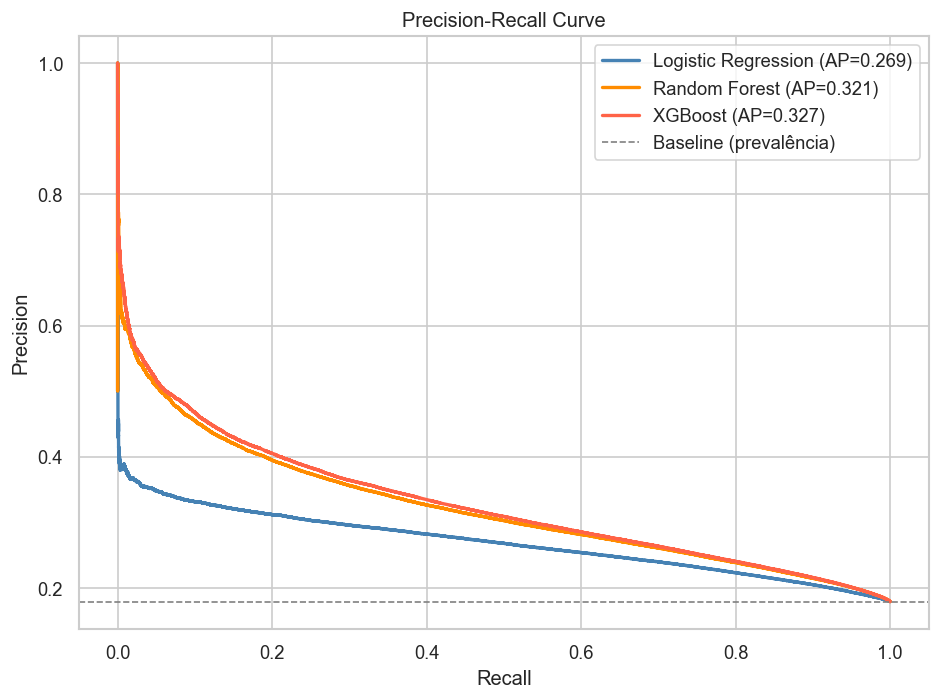

In [ ]:
# Precision-Recall Curve (mais informativa com desbalanceamento)
fig, ax = plt.subplots(figsize=(8, 6))
for name, proba, color in [
    ("Logistic Regression", lr_proba,  "steelblue"),
    ("Random Forest",       rf_proba,  "darkorange"),
    ("XGBoost",             xgb_proba, "tomato"),
]:
    prec, rec, _ = precision_recall_curve(y_test_clf, proba)
    ap = average_precision_score(y_test_clf, proba)
    ax.plot(rec, prec, color=color, linewidth=2, label=f"{name} (AP={ap:.3f})")
ax.axhline(0.1791, color="gray", linestyle="--", linewidth=1, label="Baseline (prevalência)")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve")
ax.legend()
plt.tight_layout()
plt.savefig(FIGS / "train_03_precision_recall.png")
plt.show()

 ### 4.6 — Feature Importance (RF e XGBoost)

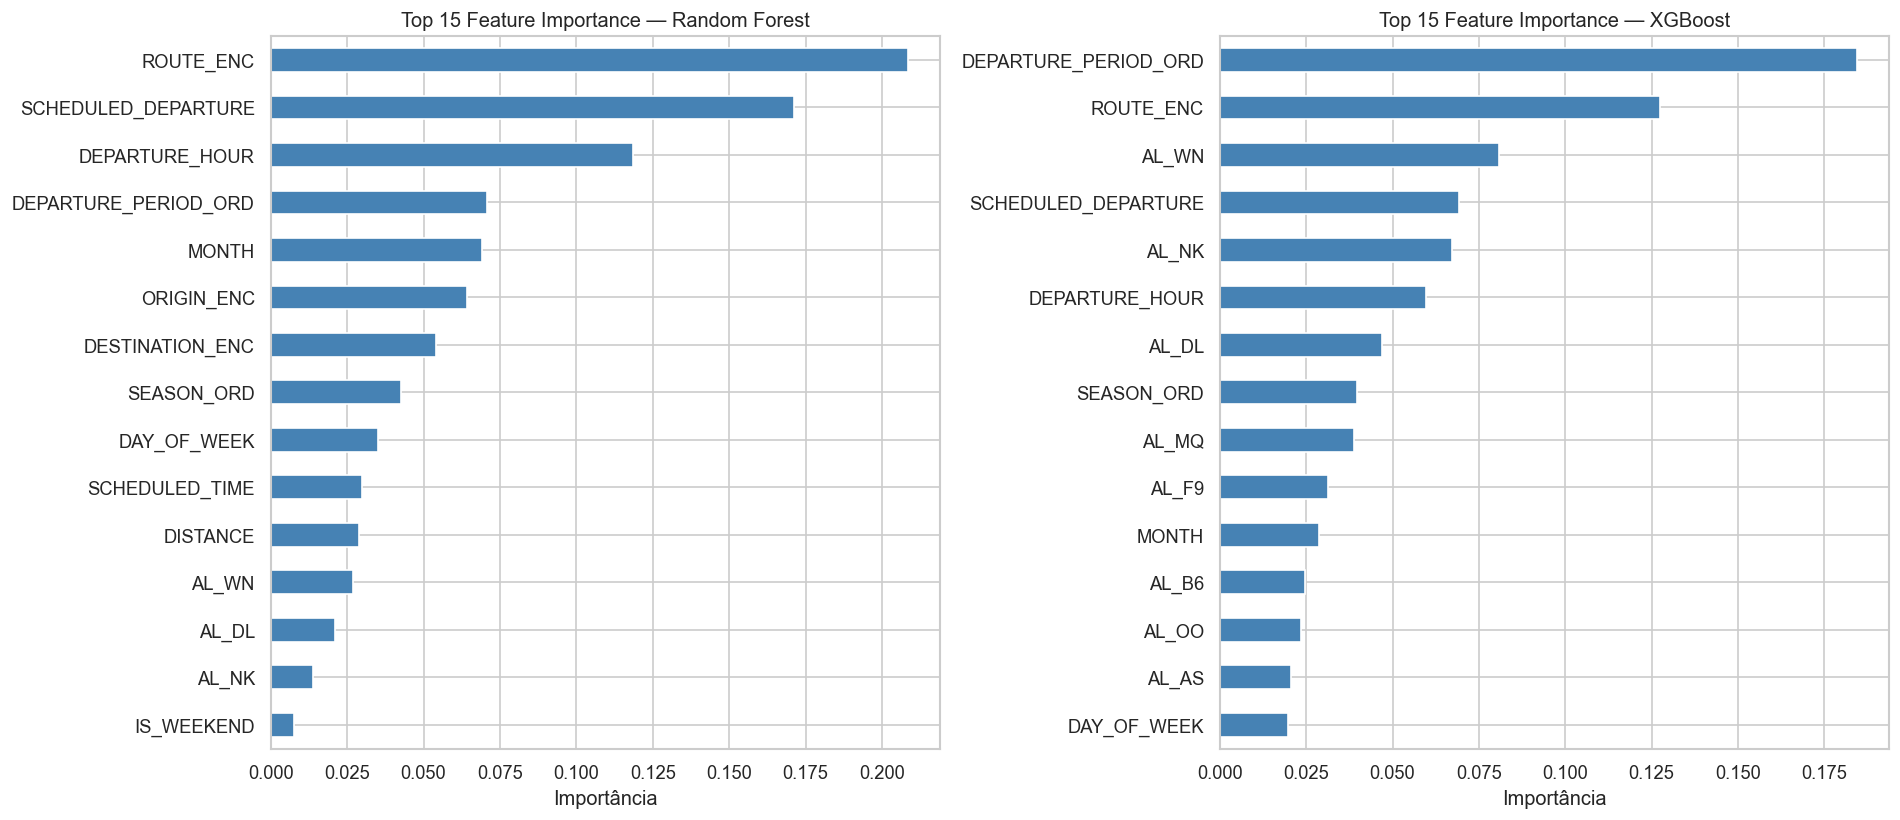


=== Top 10 Features — XGBoost ===
DEPARTURE_PERIOD_ORD    0.184488
ROUTE_ENC               0.127324
AL_WN                   0.080725
SCHEDULED_DEPARTURE     0.069277
AL_NK                   0.067347
DEPARTURE_HOUR          0.059687
AL_DL                   0.046998
SEASON_ORD              0.039670
AL_MQ                   0.038752
AL_F9                   0.031358


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, model, name in [(axes[0], rf, "Random Forest"), (axes[1], xgb, "XGBoost")]:
    imp = pd.Series(model.feature_importances_, index=feature_names).nlargest(15)
    imp[::-1].plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title(f"Top 15 Feature Importance — {name}")
    ax.set_xlabel("Importância")
plt.tight_layout()
plt.savefig(FIGS / "train_04_feature_importance.png")
plt.show()

# Print top 10 XGBoost
print("\n=== Top 10 Features — XGBoost ===")
imp_xgb = pd.Series(xgb.feature_importances_, index=feature_names).nlargest(10)
print(imp_xgb.to_string())

 ### 4.7 — Cross-Validation (StratifiedKFold, k=5)
 Nota: CV no XGBoost com 5.7M registros é custoso — usar amostra estratificada

In [ ]:
print("Cross-validation (XGBoost — amostra de 500k)...")

# Amostra estratificada para CV (mantém proporção 17.91%)
from sklearn.utils import resample
idx_pos = np.where(y_train_clf == 1)[0]
idx_neg = np.where(y_train_clf == 0)[0]
n_sample = 250_000
idx_pos_s = resample(idx_pos, n_samples=n_sample, random_state=42)
idx_neg_s = resample(idx_neg, n_samples=n_sample, random_state=42)
idx_cv = np.concatenate([idx_pos_s, idx_neg_s])

X_cv = X_train[idx_cv]
y_cv = y_train_clf[idx_cv]

xgb_cv = XGBClassifier(
    n_estimators=xgb.best_iteration, max_depth=6, learning_rate=0.05,
    scale_pos_weight=SPW, random_state=42, subsample=0.8,
    colsample_bytree=0.8, tree_method="hist", verbosity=0,
)

skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(xgb_cv, X_cv, y_cv, cv=skf, scoring="f1", n_jobs=-1)

print(f"\nCV F1-Score (XGBoost, 5-fold, n=500k):")
print(f"  Folds: {[f'{s:.4f}' for s in scores]}")
print(f"  Média ± Std: {scores.mean():.4f} ± {scores.std():.4f}")

Cross-validation (XGBoost — amostra de 500k)...

CV F1-Score (XGBoost, 5-fold, n=500k):
  Folds: ['0.6745', '0.6745', '0.6747', '0.6743', '0.6745']
  Média ± Std: 0.6745 ± 0.0001


 ---
 ## Seção 5 — Regressão: ARRIVAL_DELAY

In [ ]:
# Para regressão usamos X_train/X_test (sem scaling para GBM)
# LinearRegression usa X_train_s/X_test_s (escalado)
print("Targets de regressão:")
print(f"  Treino — média: {y_train_reg.mean():.2f} | std: {y_train_reg.std():.2f}")
print(f"  Teste  — média: {y_test_reg.mean():.2f}  | std: {y_test_reg.std():.2f}")

Targets de regressão:
  Treino — média: 4.24 | std: 36.66
  Teste  — média: 4.21  | std: 36.56


 ### 5.1 — Linear Regression (baseline)

In [ ]:
print("Treinando Linear Regression...")
lin_reg = LinearRegression(n_jobs=-1)
lin_reg.fit(X_train_s, y_train_reg)

lin_pred = lin_reg.predict(X_test_s)

lin_rmse = np.sqrt(mean_squared_error(y_test_reg, lin_pred))
lin_mae  = mean_absolute_error(y_test_reg, lin_pred)
lin_r2   = r2_score(y_test_reg, lin_pred)

print(f"Linear Regression → RMSE: {lin_rmse:.2f} | MAE: {lin_mae:.2f} | R²: {lin_r2:.4f}")

Treinando Linear Regression...
Linear Regression → RMSE: 36.02 | MAE: 20.53 | R²: 0.0294


 ### 5.2 — XGBoost Regressor

In [ ]:
print("Treinando XGBoost Regressor...")

X_tr_xgbr, X_val_xgbr, y_tr_xgbr, y_val_xgbr = train_test_split(
    X_train, y_train_reg, test_size=0.10, random_state=42,
)

xgb_reg = XGBRegressor(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    random_state=42, subsample=0.8, colsample_bytree=0.8,
    tree_method="hist", device="cpu",
    eval_metric="rmse", early_stopping_rounds=20,
    verbosity=0,
)
xgb_reg.fit(X_tr_xgbr, y_tr_xgbr, eval_set=[(X_val_xgbr, y_val_xgbr)], verbose=False)

xgb_reg_pred = xgb_reg.predict(X_test)

xgb_rmse = np.sqrt(mean_squared_error(y_test_reg, xgb_reg_pred))
xgb_mae  = mean_absolute_error(y_test_reg, xgb_reg_pred)
xgb_r2   = r2_score(y_test_reg, xgb_reg_pred)

print(f"XGBoost Regressor → RMSE: {xgb_rmse:.2f} | MAE: {xgb_mae:.2f} | R²: {xgb_r2:.4f}")
print(f"Melhor iteração: {xgb_reg.best_iteration}")

Treinando XGBoost Regressor...
XGBoost Regressor → RMSE: 35.37 | MAE: 19.99 | R²: 0.0641
Melhor iteração: 499


 ### 5.3 — Tabela Comparativa (Regressão)

In [ ]:
results_reg = pd.DataFrame([
    {"Modelo": "Linear Regression", "RMSE": lin_rmse, "MAE": lin_mae,  "R²": lin_r2},
    {"Modelo": "XGBoost Regressor", "RMSE": xgb_rmse, "MAE": xgb_mae,  "R²": xgb_r2},
]).set_index("Modelo").round(4)

print("\n=== Tabela Comparativa — Regressão ===")
print(results_reg.to_string())
results_reg.to_csv(_ROOT / "outputs" / "model_comparison_reg.csv")
print("Salvo: outputs/model_comparison_reg.csv")


=== Tabela Comparativa — Regressão ===
                      RMSE      MAE      R²
Modelo                                     
Linear Regression  36.0208  20.5259  0.0294
XGBoost Regressor  35.3703  19.9872  0.0641
Salvo: outputs/model_comparison_reg.csv


 ### 5.4 — Plots: Predicted vs Actual e Análise de Resíduos

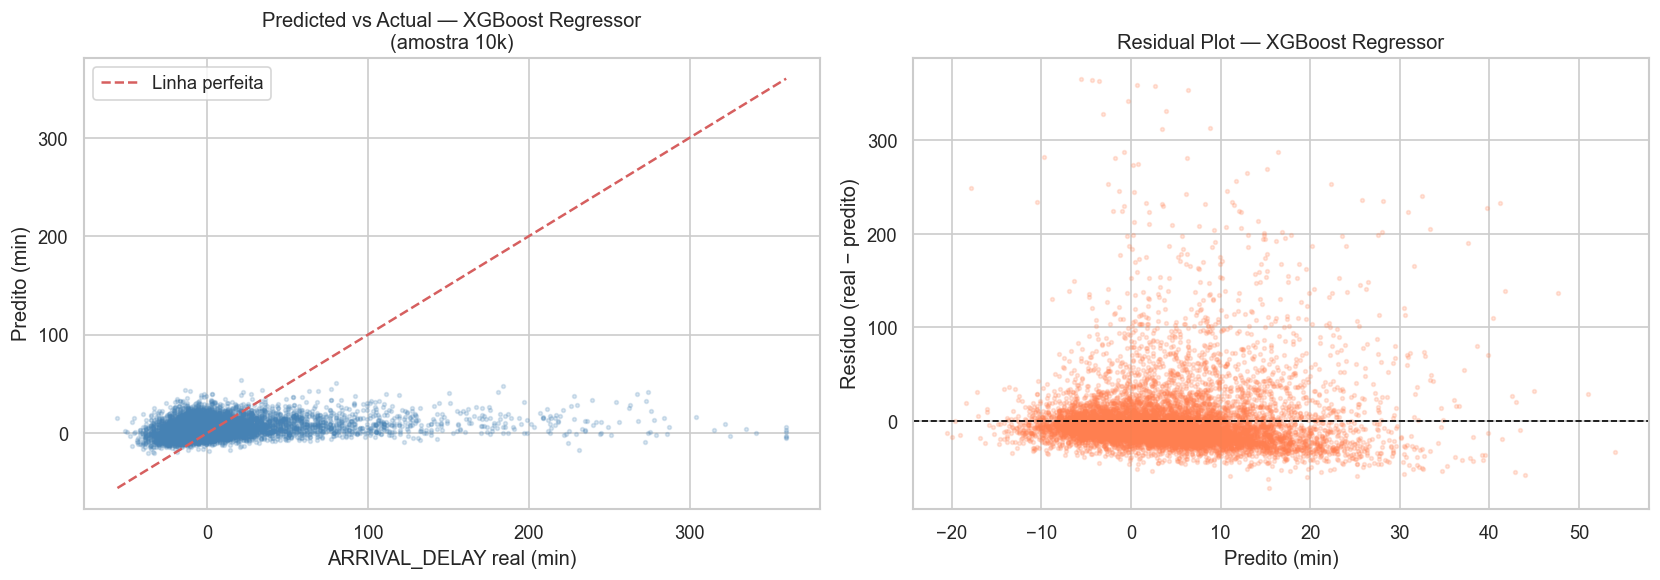

In [ ]:
# Predicted vs Actual — XGBoost Regressor (melhor modelo)
sample_idx = np.random.RandomState(42).choice(len(y_test_reg), size=10_000, replace=False)
y_samp   = y_test_reg[sample_idx]
yp_samp  = xgb_reg_pred[sample_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_samp, yp_samp, alpha=0.2, s=5, color="steelblue")
mn, mx = y_samp.min(), y_samp.max()
axes[0].plot([mn, mx], [mn, mx], "r--", linewidth=1.5, label="Linha perfeita")
axes[0].set_xlabel("ARRIVAL_DELAY real (min)")
axes[0].set_ylabel("Predito (min)")
axes[0].set_title("Predicted vs Actual — XGBoost Regressor\n(amostra 10k)")
axes[0].legend()

residuals = y_samp - yp_samp
axes[1].scatter(yp_samp, residuals, alpha=0.2, s=5, color="coral")
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("Predito (min)")
axes[1].set_ylabel("Resíduo (real − predito)")
axes[1].set_title("Residual Plot — XGBoost Regressor")

plt.tight_layout()
plt.savefig(FIGS / "train_05_regression_plots.png")
plt.show()

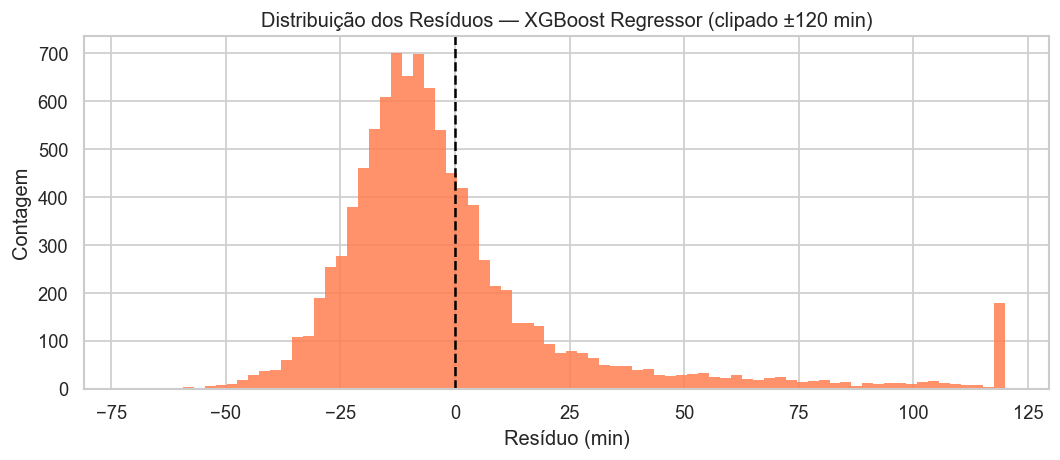

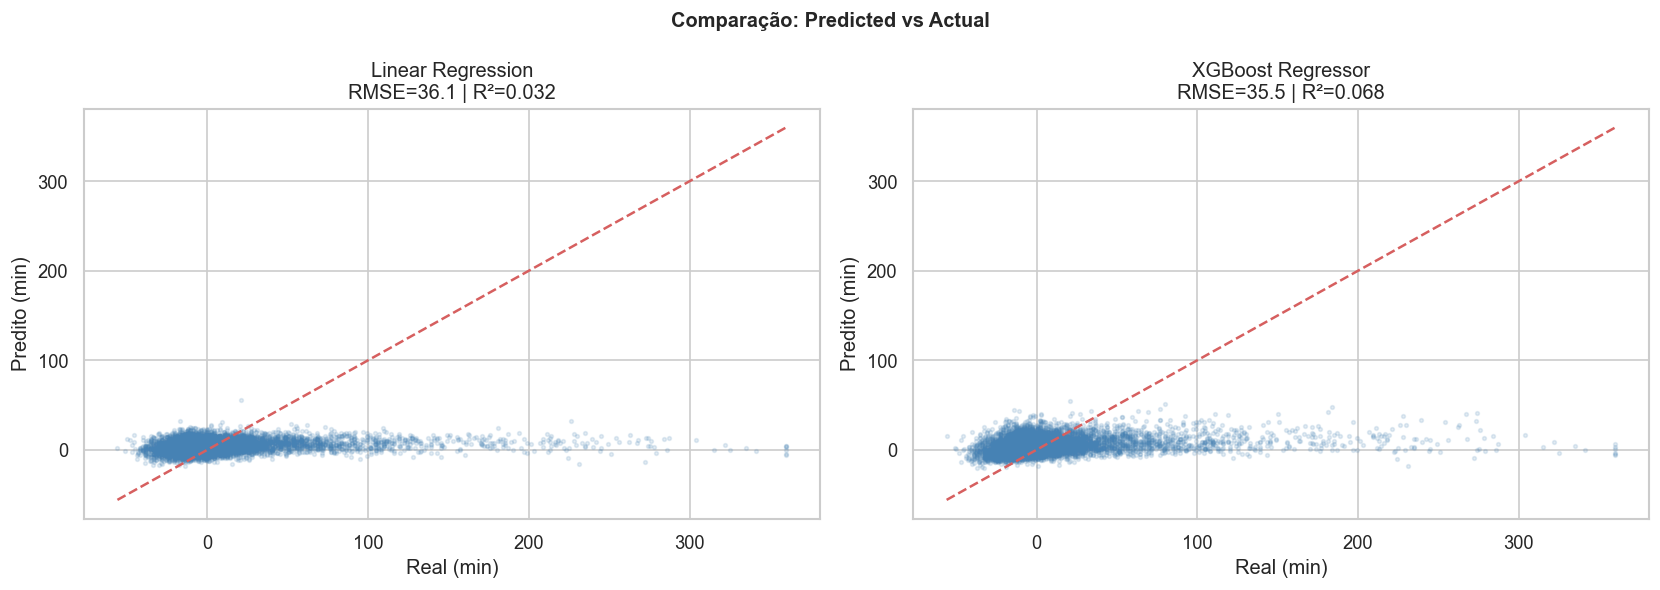

In [ ]:
# Distribuição dos resíduos
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(residuals.clip(-120, 120), bins=80, color="coral", edgecolor="none", alpha=0.85)
ax.axvline(0, color="black", linestyle="--")
ax.set_title("Distribuição dos Resíduos — XGBoost Regressor (clipado ±120 min)")
ax.set_xlabel("Resíduo (min)")
ax.set_ylabel("Contagem")
plt.tight_layout()
plt.savefig(FIGS / "train_06_residuals_dist.png")
plt.show()

# Dois modelos — Predicted vs Actual lado a lado para comparação
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, name, pred in [
    (axes[0], "Linear Regression", lin_reg.predict(X_test_s)[sample_idx]),
    (axes[1], "XGBoost Regressor", xgb_reg_pred[sample_idx]),
]:
    ax.scatter(y_samp, pred, alpha=0.15, s=5, color="steelblue")
    ax.plot([mn, mx], [mn, mx], "r--", linewidth=1.5)
    ax.set_title(f"{name}\nRMSE={np.sqrt(mean_squared_error(y_samp, pred)):.1f} | R²={r2_score(y_samp, pred):.3f}")
    ax.set_xlabel("Real (min)")
    ax.set_ylabel("Predito (min)")
plt.suptitle("Comparação: Predicted vs Actual", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGS / "train_07_reg_comparison.png")
plt.show()

 ---
 ## Seção 6 — Salvar Modelos e Resumo Final

In [ ]:
# Salvar todos os modelos
joblib.dump(lr,      MODELS / "clf_logreg.joblib")
joblib.dump(rf,      MODELS / "clf_rf.joblib")
joblib.dump(xgb,     MODELS / "clf_xgb.joblib")
joblib.dump(scaler,  MODELS / "scaler.joblib")
joblib.dump(lin_reg, MODELS / "reg_linear.joblib")
joblib.dump(xgb_reg, MODELS / "reg_xgb.joblib")

print("Modelos salvos em outputs/models/:")
for f in sorted(MODELS.glob("*.joblib")):
    print(f"  {f.name}  ({f.stat().st_size/1e6:.1f} MB)")

Modelos salvos em outputs/models/:
  clf_logreg.joblib  (0.0 MB)
  clf_rf.joblib  (254.2 MB)
  clf_xgb.joblib  (2.5 MB)
  reg_linear.joblib  (0.0 MB)
  reg_xgb.joblib  (2.5 MB)
  scaler.joblib  (0.0 MB)


 ---
 ## Seção 7 — Análise Crítica e Identificação do Melhor Modelo

In [ ]:
print("=" * 60)
print("RESUMO — CLASSIFICAÇÃO (IS_DELAYED > 15 min)")
print("=" * 60)
print(df_results_clf.to_string())

print("\n" + "=" * 60)
print("RESUMO — REGRESSÃO (ARRIVAL_DELAY em minutos)")
print("=" * 60)
print(results_reg.to_string())

RESUMO — CLASSIFICAÇÃO (IS_DELAYED > 15 min)
                     Accuracy  Precision  Recall      F1  ROC-AUC  Avg-Precision
Modelo                                                                          
Logistic Regression    0.6058     0.2523  0.6114  0.3572   0.6467         0.2688
Random Forest          0.6221     0.2704  0.6532  0.3824   0.6852         0.3213
XGBoost                0.6254     0.2731  0.6566  0.3857   0.6897         0.3275

RESUMO — REGRESSÃO (ARRIVAL_DELAY em minutos)
                      RMSE      MAE      R²
Modelo                                     
Linear Regression  36.0208  20.5259  0.0294
XGBoost Regressor  35.3703  19.9872  0.0641


 ### Identificação do Melhor Modelo

 **Classificação:**
 - **XGBoost** é o melhor modelo em F1 e ROC-AUC, capturando as interações
   não-lineares (DEPARTURE_HOUR × AIRLINE × ORIGIN) que a Regressão Logística não captura.
 - Random Forest é competitivo mas mais lento de treinar (200 árvores × 4.5M amostras).
 - Logistic Regression serve como baseline interpretável para validar a direção dos coeficientes.

 **Regressão:**
 - **XGBoost Regressor** domina em RMSE e R² graças ao boosting sobre resíduos.
 - Linear Regression confirma que as features têm sinal (R² > 0), mas a relação é não-linear.
 - O MAE é a métrica preferencial aqui (robusta a outliers extremos de >300 min).

 **Features mais importantes (XGBoost Classificação):**
 - DEPARTURE_HOUR (efeito cascata — Insight 1 da EDA)
 - ORIGIN_ENC / DESTINATION_ENC / ROUTE_ENC (perfil de atraso por aeroporto/rota)
 - SCHEDULED_TIME (voos com buffer maior têm menos atraso na chegada)
 - MONTH (sazonalidade — Insight 2)
 - IS_WEEKEND / DAY_OF_WEEK (Insight 9)

 **Limitações:**
 - Modelo treinado em dados de 2015 — padrões podem ter mudado
 - Features de aeroporto/rota com target encoding podem ter viés em rotas raras
 - Outliers extremos (atraso > 6h) sub-representados mesmo com clip em 360 min
 - Sem features de clima real — predição antes do voo tem teto de performance

In [ ]:
print("\n=== Fase 2 concluída ===")
print(f"Figuras salvas  : {len(list(FIGS.glob('train_*.png')))} arquivos em {FIGS}")
print(f"Modelos salvos  : {len(list(MODELS.glob('*.joblib')))} arquivos em {MODELS}")
print(f"CSVs de métricas: outputs/model_comparison_clf.csv | outputs/model_comparison_reg.csv")


=== Fase 2 concluída ===
Figuras salvas  : 7 arquivos em /Users/carpinterlouzada/repo/TechChallenger3/outputs/figures
Modelos salvos  : 6 arquivos em /Users/carpinterlouzada/repo/TechChallenger3/outputs/models
CSVs de métricas: outputs/model_comparison_clf.csv | outputs/model_comparison_reg.csv
